In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

%load_ext autoreload
%autoreload 2

In [4]:
def parse_results(results_dir):
    """
    Parses all *_results.json files in a directory and returns a pandas DataFrame.
    """
    all_results = []
    json_files = glob.glob(os.path.join(results_dir, "*_results.json"))

    for file_path in json_files:
        with open(file_path, "r") as f:
            data = json.load(f)
            # The file name without the path and extension can be used as an identifier
            file_id = os.path.basename(file_path).replace("_results.json", "")
            result = {
                "id": int(file_id),
                "target_problem": data["parameters"]["data_file"],
                "kde_bandwidth": data["parameters"]["model__kde_bandwidth"],
                "n_kde": data["parameters"]["model__n_kde"],
                "n_uniform": data["parameters"]["model__n_uniform"],
                "kl_divergence": data["metrics"]["total"]["kl_divergence"],
                "num_success": data["metrics"]["total"]["num_success"],
            }
            all_results.append(result)

    df = pd.DataFrame(all_results)
    df = df.sort_values(by="id").reset_index(drop=True)
    return df


def visualize_results(df, title="Results Summary"):
    """
    Visualizes the parsed results.
    """
    print("Parsed data:")
    print(df)

    plt.figure(figsize=(15, 5))
    plt.suptitle(title)

    plt.subplot(1, 3, 1)
    sns.scatterplot(data=df, x="kde_bandwidth", y="kl_divergence", hue="num_success")
    plt.title("KL Divergence vs. KDE Bandwidth")
    plt.xscale("log")

    plt.subplot(1, 3, 2)
    sns.scatterplot(data=df, x="n_kde", y="kl_divergence", hue="num_success")
    plt.title("KL Divergence vs. N KDE")

    plt.subplot(1, 3, 3)
    sns.scatterplot(data=df, x="n_uniform", y="kl_divergence", hue="num_success")
    plt.title("KL Divergence vs. N Uniform")

    plt.tight_layout()
    plt.show()


Results for problem: zhong/f01/f01.csv
Parsed data:
    id     target_problem  kde_bandwidth  n_kde  n_uniform  kl_divergence  \
0    1  zhong/f01/f01.csv       0.023170    355        183   1.573738e-03   
1    2  zhong/f01/f01.csv     204.580157    422        455  -6.991324e-05   
2    3  zhong/f01/f01.csv     372.171694    297        333  -4.278135e-05   
3    4  zhong/f01/f01.csv       0.000002    247         17   1.278941e-03   
4    5  zhong/f01/f01.csv    3910.901158    454         37   1.274555e-04   
5    6  zhong/f01/f01.csv       0.003543    259        380   3.018279e-03   
6    7  zhong/f01/f01.csv  239114.534959    345        150  -3.408815e-04   
7    8  zhong/f01/f01.csv       0.000055    174        439   3.714655e-03   
8    9  zhong/f01/f01.csv   53525.079015    139        308  -9.603622e-07   
9   10  zhong/f01/f01.csv       0.000936    330        340   2.249279e-03   
10  11  zhong/f01/f01.csv       6.102849    369        284  -8.776060e-05   
11  12  zhong/f01/f01.c

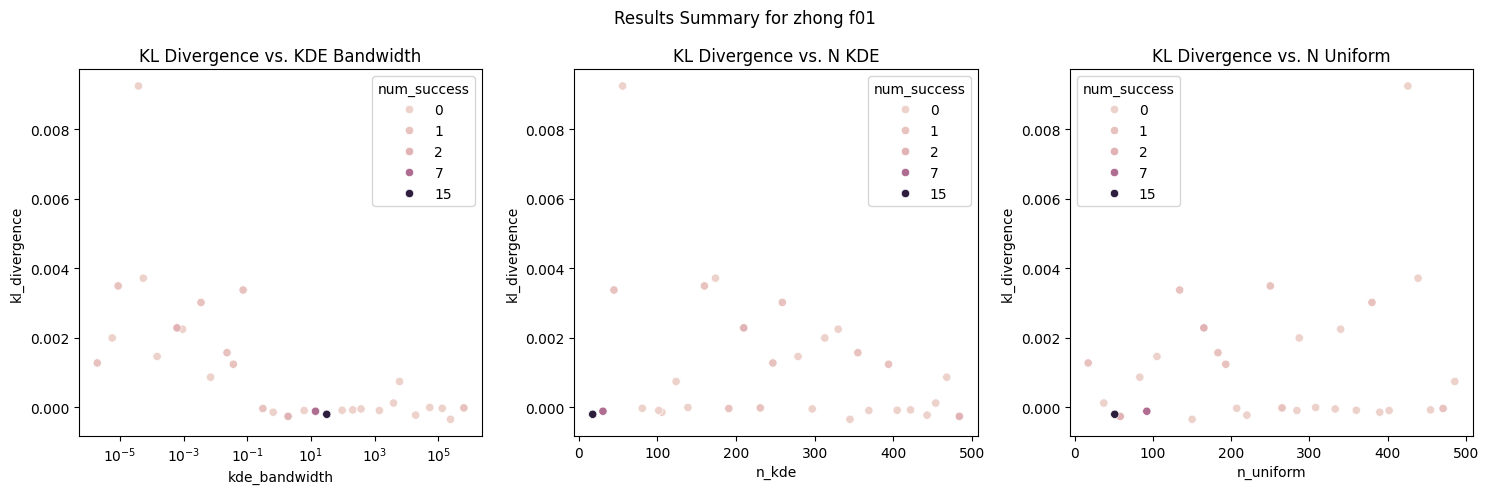

In [ ]:
# results_directory = "../results/gplearn_20251104-113048"
results_directory = "../results/gplearn_20251209-130641"
results_df = parse_results(results_directory)
for problem, group in results_df.groupby("target_problem"):
    print(f"\nResults for problem: {problem}")
    visualize_results(
        group,
        title=f"Results Summary for {str(problem).replace('/', ' ')[:-8]}",
    )